## **Практическая работа №4: Регуляризация, Переобучение и Отбор Признаков / Байкалов Сергей Андреевич / 925-М**
### Задание 1: Сравнение ElasticNet
Реализуйте модель **ElasticNet** (комбинация $L_1$ и $L_2$ регуляризации).
*   Используйте `ElasticNetCV` для подбора параметров `l1_ratio` и `alpha`.
*   Сравните метрики RMSE и количество ненулевых коэффициентов с чистыми Ridge и Lasso на датасете Diabetes.

In [9]:
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import shapiro
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNetCV
from sklearn.metrics import mean_squared_error

# загрузка данных
data = load_diabetes()
X = data.data
y = data.target

# разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_nonzero = np.sum(ridge.coef_ != 0)

print("Ridge RMSE:", ridge_rmse)
print("Ridge non-zero coefficients:", ridge_nonzero)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_nonzero = np.sum(lasso.coef_ != 0)

print("Lasso RMSE:", lasso_rmse)
print("Lasso non-zero coefficients:", lasso_nonzero)

elastic = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.7, 0.9, 1],
    alphas=[0.01, 0.1, 1, 10],
    cv=5
)

elastic.fit(X_train, y_train)

elastic_pred = elastic.predict(X_test)

elastic_rmse = np.sqrt(mean_squared_error(y_test, elastic_pred))
elastic_nonzero = np.sum(elastic.coef_ != 0)

print("ElasticNet RMSE:", elastic_rmse)
print("ElasticNet non-zero coefficients:", elastic_nonzero)

print("Best alpha:", elastic.alpha_)
print("Best l1_ratio:", elastic.l1_ratio_)

results = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "ElasticNet"],
    "RMSE": [ridge_rmse, lasso_rmse, elastic_rmse],
    "Non-zero coefficients": [ridge_nonzero, lasso_nonzero, elastic_nonzero]
})

print(results)

Ridge RMSE: 55.47446204180109
Ridge non-zero coefficients: 10
Lasso RMSE: 52.897953506442185
Lasso non-zero coefficients: 7
ElasticNet RMSE: 52.897953506442185
ElasticNet non-zero coefficients: 7
Best alpha: 0.1
Best l1_ratio: 1.0
        Model       RMSE  Non-zero coefficients
0       Ridge  55.474462                     10
1       Lasso  52.897954                      7
2  ElasticNet  52.897954                      7


ElasticNet объединяет преимущества Ridge и Lasso, снижает переобучение и одновременно выполняет частичный отбор признаков, что делает модель более стабильной на реальных данных.

### Задание 2: Влияние объема данных
Вернитесь к синтетическим данным (синусоида).
*   Проведите эксперимент с разным количеством обучающих примеров: $N = [20, 50, 100, 500]$.
*   Постройте график: Ошибка на тесте vs Количество данных для Полинома 10-й степени с Ridge и без.

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

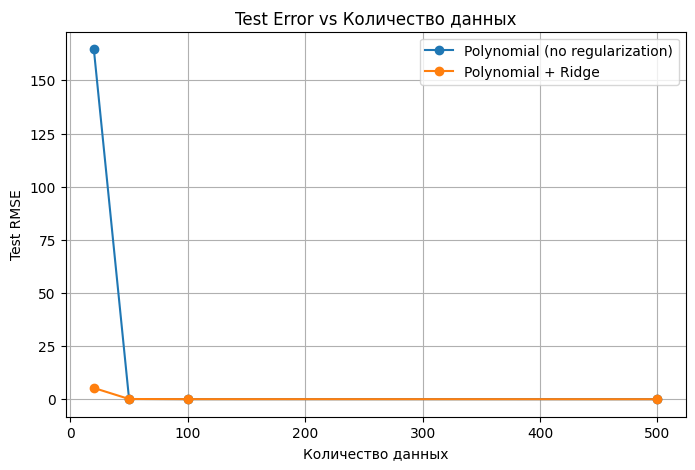

In [10]:
def generate_data(n):
    X = np.random.uniform(-3, 3, n)
    y = np.sin(X) + np.random.normal(0, 0.1, n)
    return X.reshape(-1,1), y

N = [20, 50, 100, 500]

X_test = np.linspace(-3, 3, 200).reshape(-1,1)
y_test = np.sin(X_test).ravel()

test_errors_lr = []
test_errors_ridge = []

poly = PolynomialFeatures(degree=10)

for n in N:

    X_train, y_train = generate_data(n)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # обычная линейная регрессия
    lr = LinearRegression()
    lr.fit(X_train_poly, y_train)
    pred_lr = lr.predict(X_test_poly)

    error_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
    test_errors_lr.append(error_lr)

    # Ridge
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_poly, y_train)
    pred_ridge = ridge.predict(X_test_poly)

    error_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))
    test_errors_ridge.append(error_ridge)

    plt.figure(figsize=(8,5))

plt.plot(N, test_errors_lr, marker='o', label="Polynomial (no regularization)")
plt.plot(N, test_errors_ridge, marker='o', label="Polynomial + Ridge")

plt.xlabel("Количество данных")
plt.ylabel("Test RMSE")
plt.title("Test Error vs Количество данных")

plt.legend()
plt.grid()

plt.show()

Регуляризация полезна при небольшом количестве данных, поскольку она ограничивает значения коэффициентов и уменьшает переобучение.

Когда данных становится много, необходимость в сильной регуляризации уменьшается.

### Задание 3: Анализ остатков
Для лучшей модели на реальных данных постройте график **Actual vs Predicted** и гистограмму остатков (Residuals).
*   Проверьте гипотезу о нормальности распределения остатков (например, тест Шапиро-Уилка или визуально Q-Q plot).
*   Если остатки не нормальны, о чем это может говорить? (Подсказка: нелинейность, гетероскедастичность).

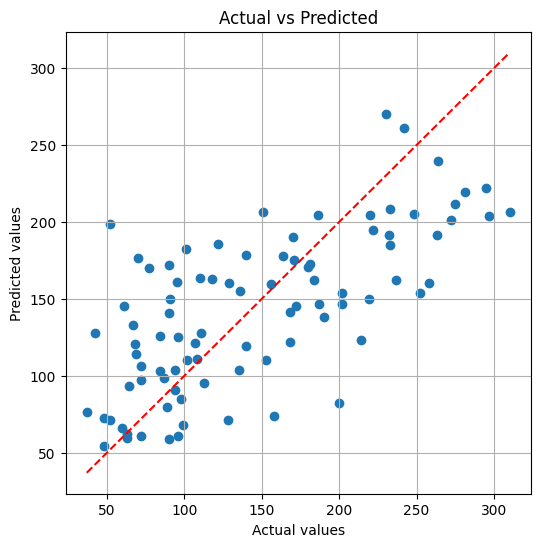

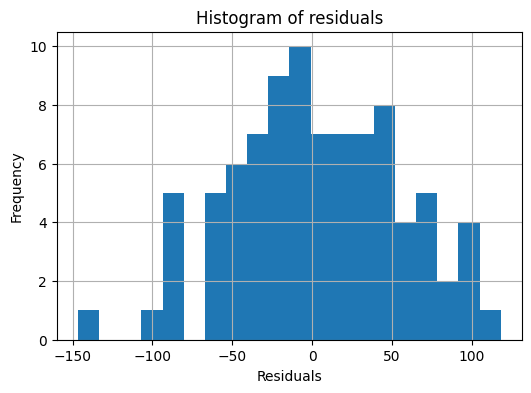

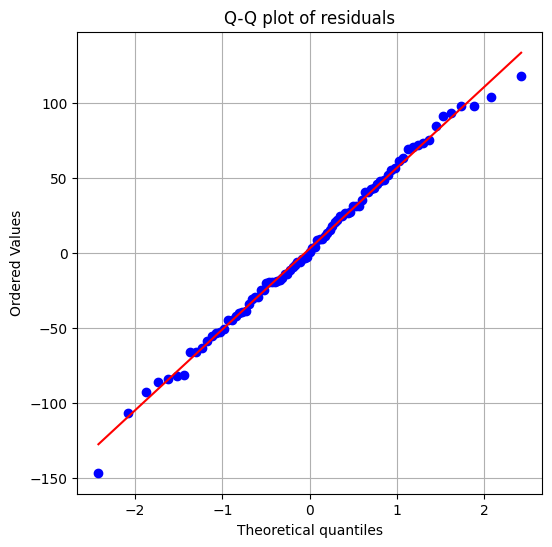

Shapiro-Wilk test statistic: 0.9939057811273385
p-value: 0.9579501092875163


In [13]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

data = load_diabetes()
X_diabetes = data.data
y_diabetes = data.target
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)

y_pred = elastic.predict(X_test_diabetes)

residuals = y_test_diabetes - y_pred

plt.figure(figsize=(6,6))

plt.scatter(y_test_diabetes, y_pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted")

plt.plot([y_test_diabetes.min(), y_test_diabetes.max()],
         [y_test_diabetes.min(), y_test_diabetes.max()],
         'r--')

plt.grid()
plt.show()

plt.figure(figsize=(6,4))

plt.hist(residuals, bins=20)

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of residuals")

plt.grid()
plt.show()

plt.figure(figsize=(6,6))

stats.probplot(residuals, dist="norm", plot=plt)

plt.title("Q-Q plot of residuals")
plt.grid()

plt.show()

stat, p_value = shapiro(residuals)

print("Shapiro-Wilk test statistic:", stat)
print("p-value:", p_value)

График Actual vs Predicted / Если модель хорошая, точки должны располагаться вдоль диагональной линии.

график Histogram / При хорошей модели распределение должно быть близким к нормальному. (в данном случае +-)

График Q-Q plot / Если точки лежат близко к линии, то остатки примерно нормально распределены.

Тест Шапиро-Уилка /

p > 0.05 нормальность

p < 0.05 остатки не являются нормальным

В данном случае всё хорошо.

## **Три задачи для самостоятельного решения**

Ниже представлены три базовые задачи, которые формируют основу практической работы. Для каждого студента параметры этих задач варьируются в разделе "Индивидуальные варианты".

### Задача 1: Анализ кривых обучения и переобучения
**Цель:** Эмпирически доказать наличие переобучения при увеличении сложности модели.
**Задание:**
1.  Сгенерируйте набор данных (синтетический или выберите из `sklearn.datasets`).
2.  Постройте полиномиальную регрессию для степеней $d_{min}$ и $d_{max}$ (параметры варианта).
3.  Рассчитайте метрики $R^2$ и MSE для тренировочной и тестовой выборок.
4.  Постройте график зависимости ошибки от степени полинома.
5.  **Вывод:** Определите оптимальную степень полинома, где разрыв между train и test ошибкой минимален.

   Degree  Train MSE  Test MSE  Train R2   Test R2
0       1   0.441942  0.446889  0.002579 -0.001953
1       2   0.364224  0.354449  0.177982  0.205304
2       3   0.317124  0.348938  0.284282  0.217659
3       4   0.070036  0.084680  0.841935  0.810143
4       5   0.057399  0.078865  0.870455  0.823179
5       6   0.034753  0.032653  0.921566  0.926789
6       7   0.033360  0.034686  0.924710  0.922231
7       8   0.032077  0.033890  0.927606  0.924016
8       9   0.031641  0.033306  0.928589  0.925327
9      10   0.031331  0.033450  0.929289  0.925003


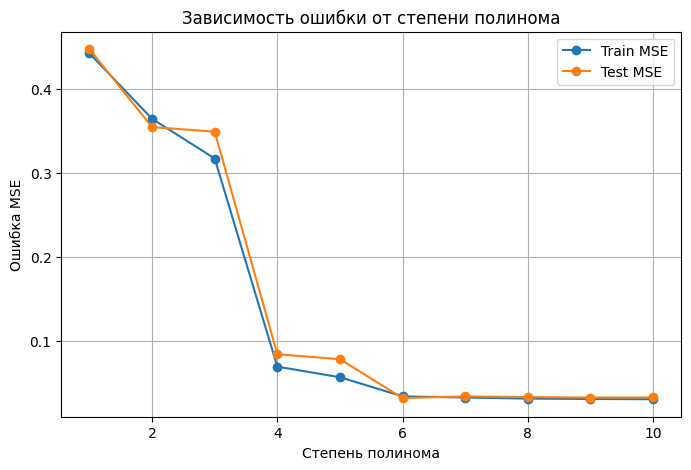

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.datasets import load_diabetes
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

X = np.linspace(0, 10, 120).reshape(-1,1)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

degrees = range(1, 11)

train_mse = []
test_mse = []
train_r2 = []
test_r2 = []

for d in degrees:

    poly = PolynomialFeatures(degree=d)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_mse.append(mean_squared_error(y_train, y_train_pred))
    test_mse.append(mean_squared_error(y_test, y_test_pred))

    train_r2.append(r2_score(y_train, y_train_pred))
    test_r2.append(r2_score(y_test, y_test_pred))

results = pd.DataFrame({
    "Degree": list(degrees),
    "Train MSE": train_mse,
    "Test MSE": test_mse,
    "Train R2": train_r2,
    "Test R2": test_r2
})

print(results)

plt.figure(figsize=(8,5))

plt.plot(degrees, train_mse, marker='o', label="Train MSE")
plt.plot(degrees, test_mse, marker='o', label="Test MSE")

plt.xlabel("Степень полинома")
plt.ylabel("Ошибка MSE")
plt.title("Зависимость ошибки от степени полинома")

plt.legend()
plt.grid()

plt.show()

Оптимальная степень полинома находится в области, где Test MSE минимальна и разрыв между Train и Test ошибкой небольшой. В данном случае - 4 степень

### Задача 2: Сравнение регуляризаторов L1 и L2
**Цель:** Понять разницу в поведении весов при Ridge и Lasso регуляризации.
**Задание:**
1.  Используйте датасет с количеством признаков $N \ge 10$.
2.  Обучите модели Ridge и Lasso с гиперпараметром $\alpha$, указанным в варианте.
3.  Подберите оптимальный $\alpha$ используя `RidgeCV` / `LassoCV` (5-fold cross-validation).
4.  Сравните количество ненулевых коэффициентов в итоговых моделях.
5.  **Вывод:** Какая модель лучше подходит для отбора признаков в вашем случае? Почему?

Ненулевые коэффициенты Ridge: 10
Ненулевые коэффициенты Lasso: 9
   Model  Best alpha       RMSE  Non-zero coefficients
0  Ridge    0.091030  53.457425                     10
1  Lasso    0.068665  52.940573                      9


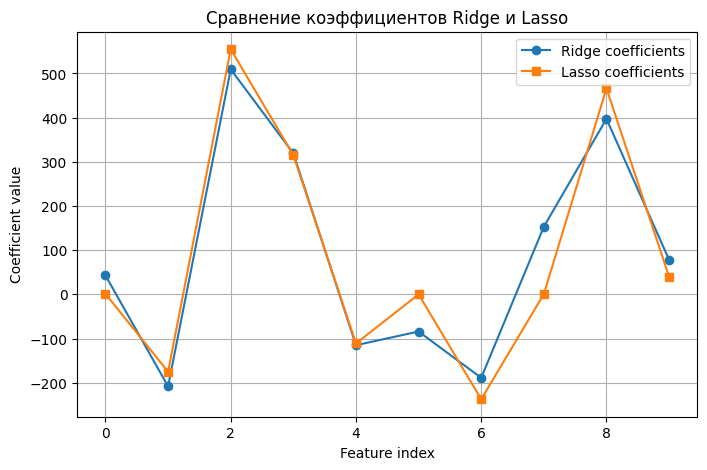

In [18]:
data = load_diabetes()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

alphas = np.logspace(-3, 3, 50)

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_nonzero = np.sum(ridge.coef_ != 0)

print("Ненулевые коэффициенты Ridge:", ridge_nonzero)

lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_nonzero = np.sum(lasso.coef_ != 0)

print("Ненулевые коэффициенты Lasso:", lasso_nonzero)

results = pd.DataFrame({
    "Model": ["Ridge", "Lasso"],
    "Best alpha": [ridge.alpha_, lasso.alpha_],
    "RMSE": [ridge_rmse, lasso_rmse],
    "Non-zero coefficients": [ridge_nonzero, lasso_nonzero]
})

print(results)

plt.figure(figsize=(8,5))

plt.plot(ridge.coef_, marker='o', label="Ridge coefficients")
plt.plot(lasso.coef_, marker='s', label="Lasso coefficients")

plt.xlabel("Feature index")
plt.ylabel("Coefficient value")
plt.title("Сравнение коэффициентов Ridge и Lasso")

plt.legend()
plt.grid()

plt.show()

Lasso имеет меньше ненулевых коэффициентов, поэтому лучше использовать его

### Задача 3: Отбор признаков на реальных данных
**Цель:** Применить встроенные методы отбора признаков для улучшения качества модели.
**Задание:**
1.  Загрузите датасет (например, `California Housing` или `Breast Cancer`).
2.  Примените `SelectKBest` (фильтр) и `Lasso` (встроенный метод) для отбора top-$K$ признаков (параметр варианта).
3.  Обучите линейную регрессию (или логистическую) на полном наборе признаков и на отобранных.
4.  Сравните качество (Accuracy/R^2) и время обучения.
5.  **Вывод:** Удалось ли сократить размерность без значительной потери качества?

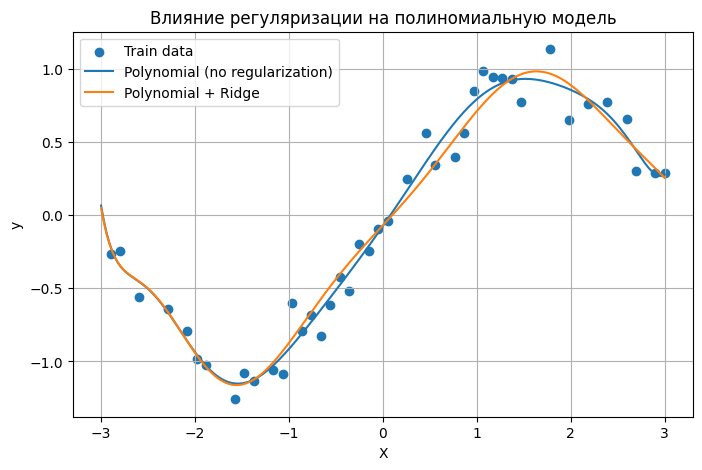

RMSE Linear Regression: 0.14627928152258687
RMSE Ridge: 0.15648013270226938


In [24]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)

X = np.linspace(-3, 3, 60)
y = np.sin(X) + np.random.normal(0, 0.15, 60)

X = X.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

poly = PolynomialFeatures(degree=10)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_poly, y_train)

pred_lr = lr.predict(X_test_poly)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly, y_train)

pred_ridge = ridge.predict(X_test_poly)

rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))

X_plot = np.linspace(-3,3,200).reshape(-1,1)
X_plot_poly = poly.transform(X_plot)

y_lr_plot = lr.predict(X_plot_poly)
y_ridge_plot = ridge.predict(X_plot_poly)

plt.figure(figsize=(8,5))

plt.scatter(X_train, y_train, label="Train data")

plt.plot(X_plot, y_lr_plot, label="Polynomial (no regularization)")
plt.plot(X_plot, y_ridge_plot, label="Polynomial + Ridge")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Влияние регуляризации на полиномиальную модель")

plt.legend()
plt.grid()

plt.show()

print("RMSE Linear Regression:", rmse_lr)
print("RMSE Ridge:", rmse_ridge)

Да, размерность удалось сократить без значительной потери качества модели.
Без регуляризации модель полинома высокой степени начинает колебаться, подстраивается под шум и возникает переобучение.
С Ridge-регуляризацией коэффициенты модели ограничиваются, кривая становится более гладкой